 Matplotlib: Демонстрация основных типов графиков


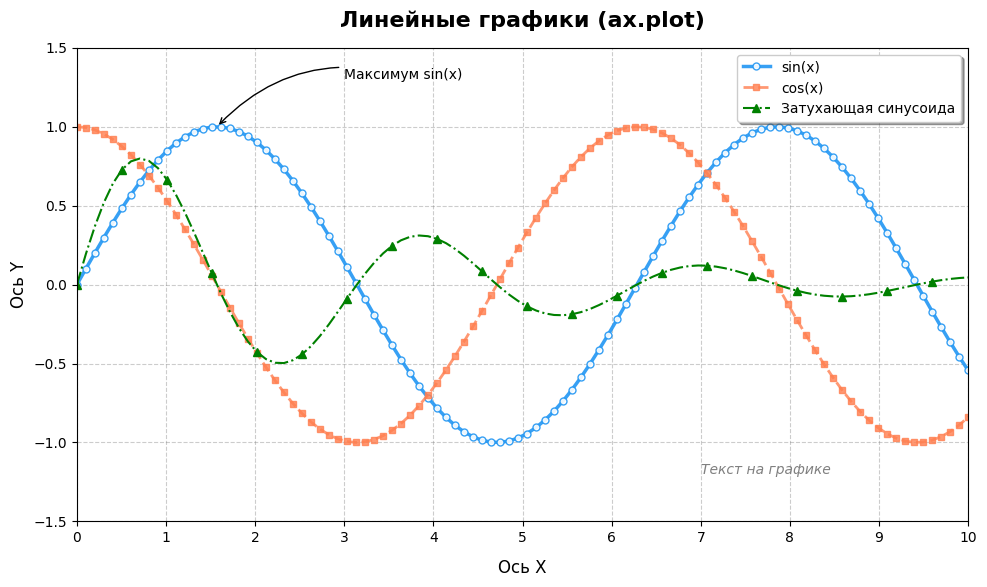

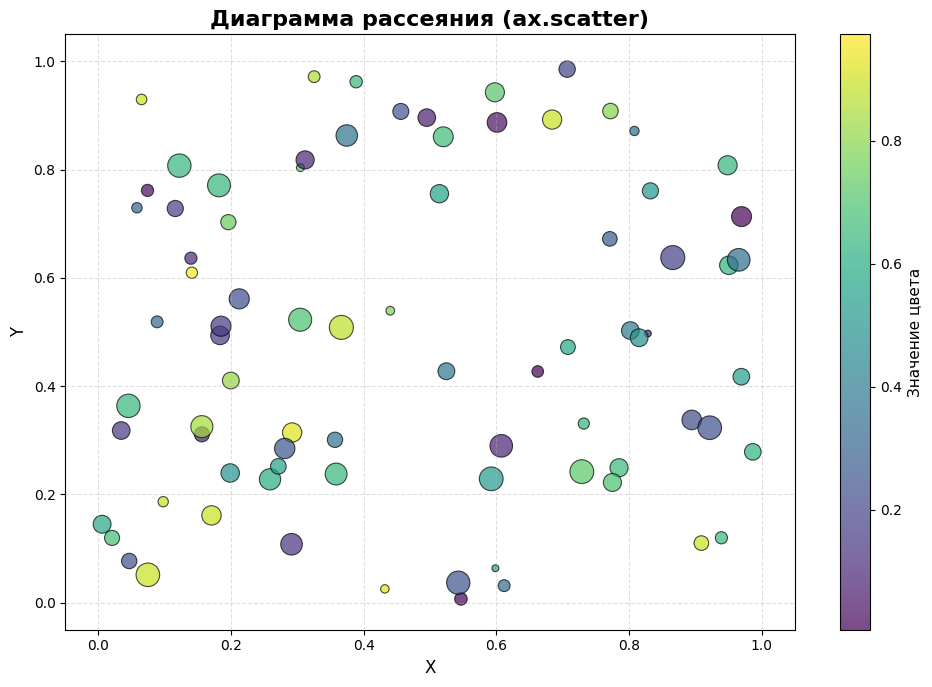

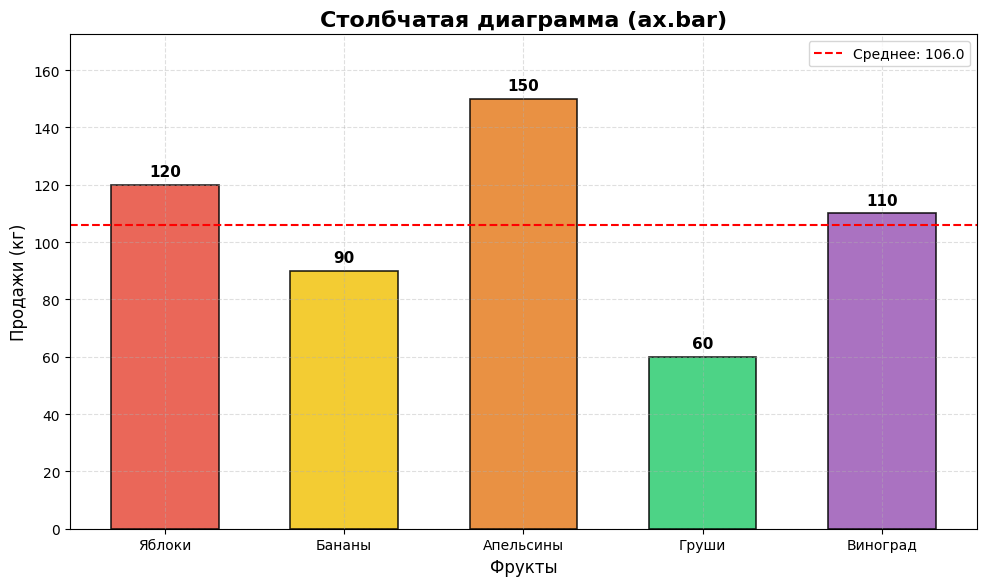

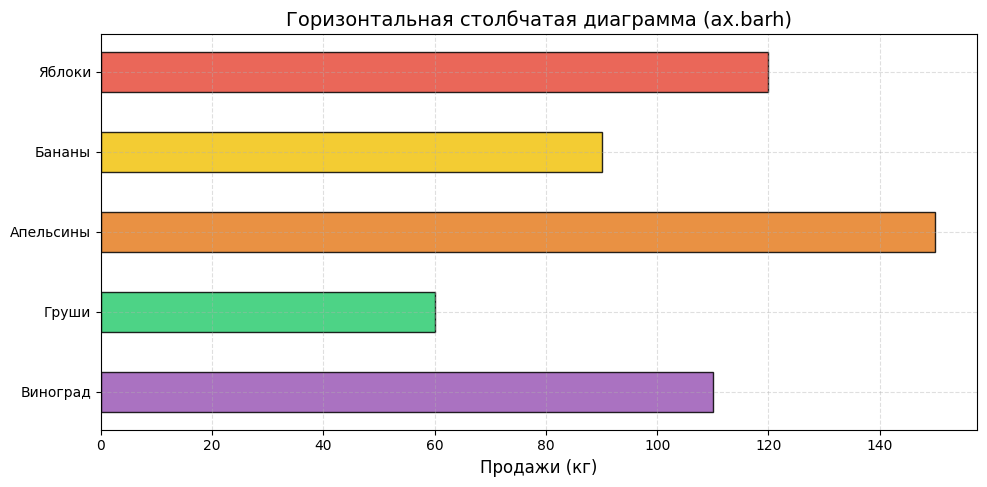

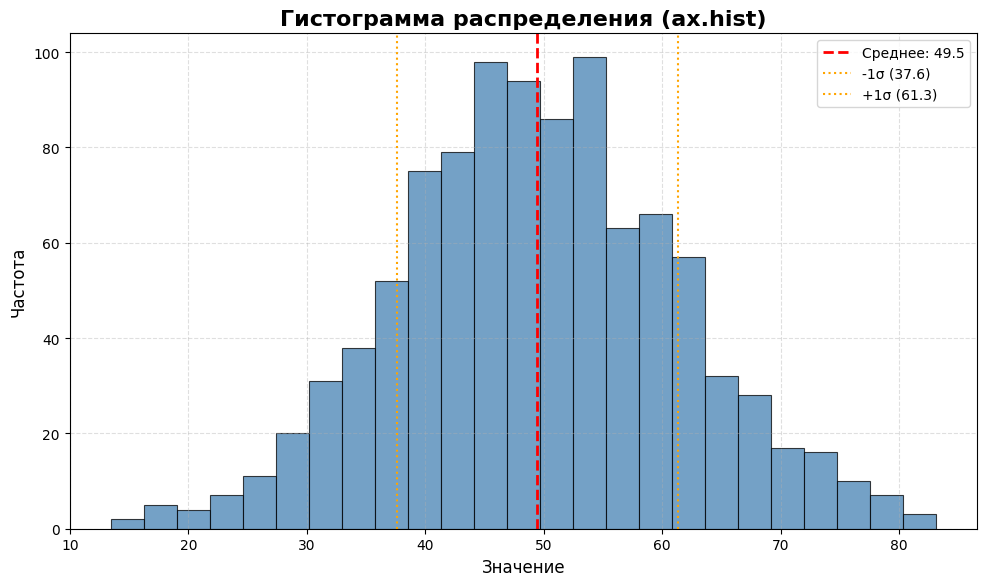

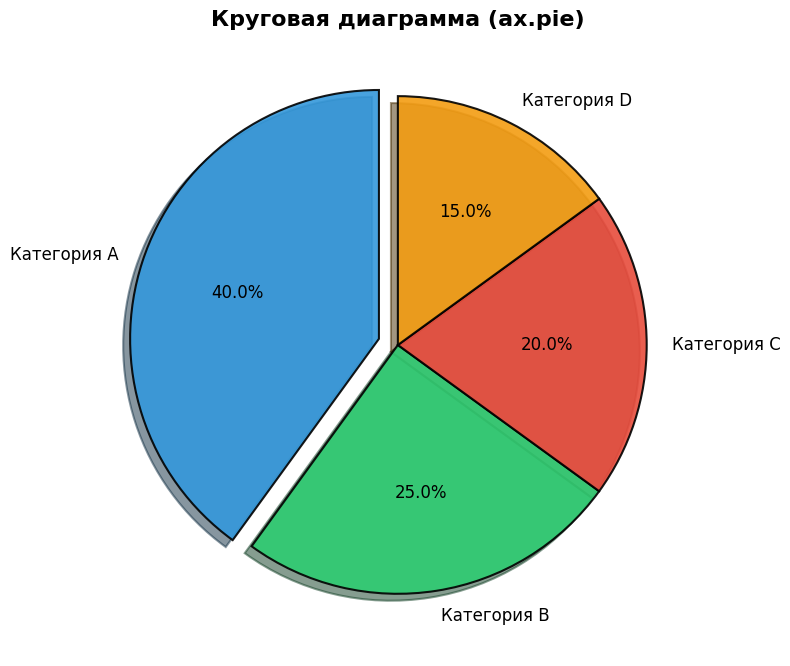

/tmp/ipykernel_408/4161955098.py:494: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


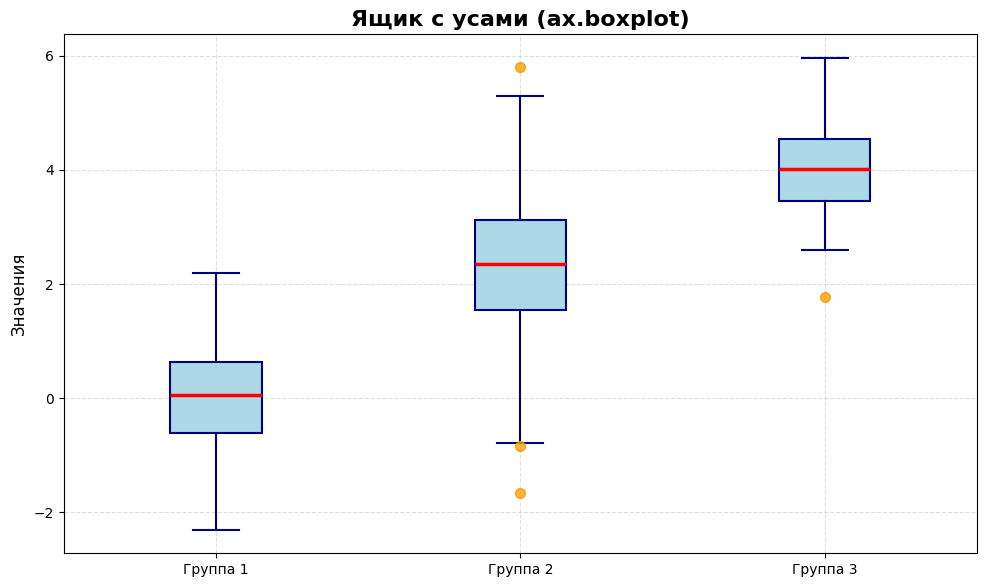

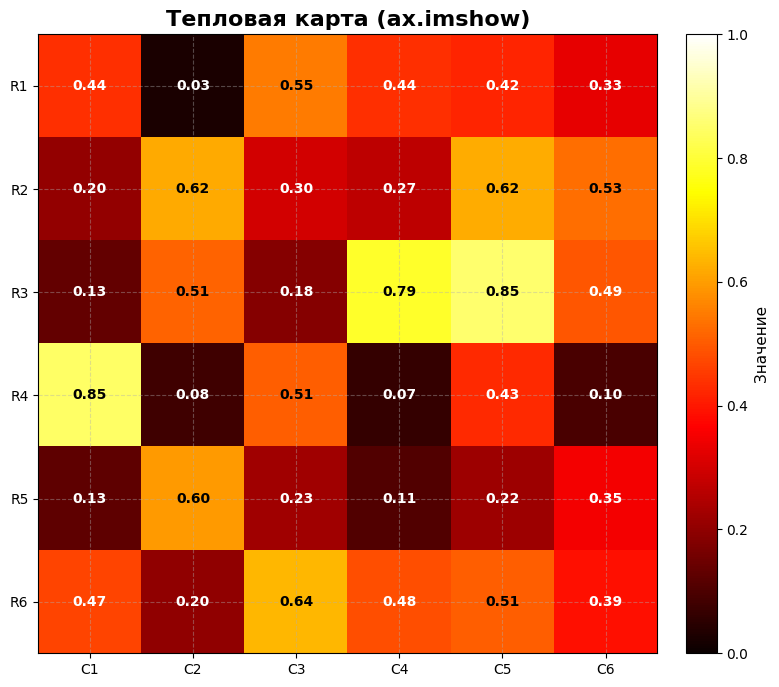

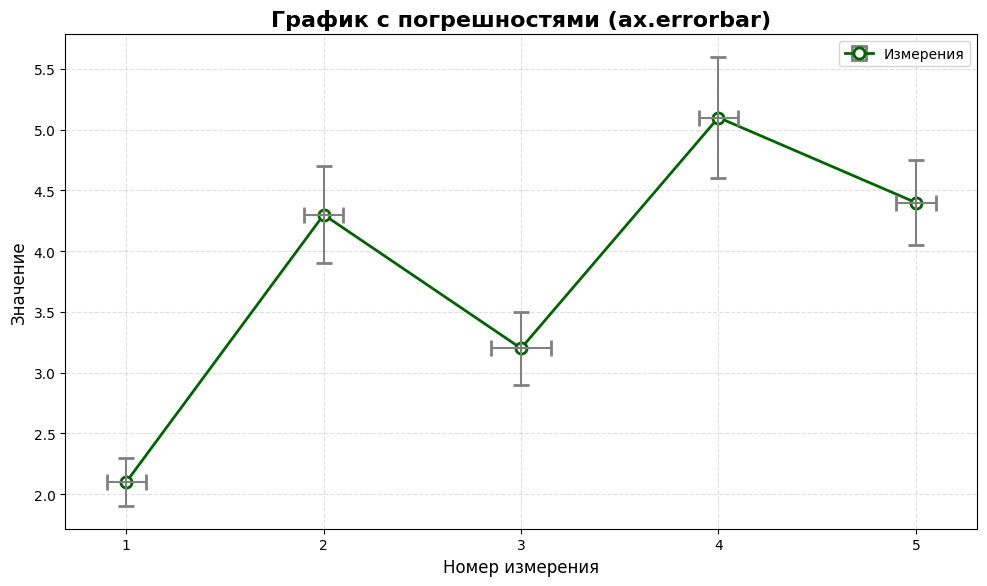

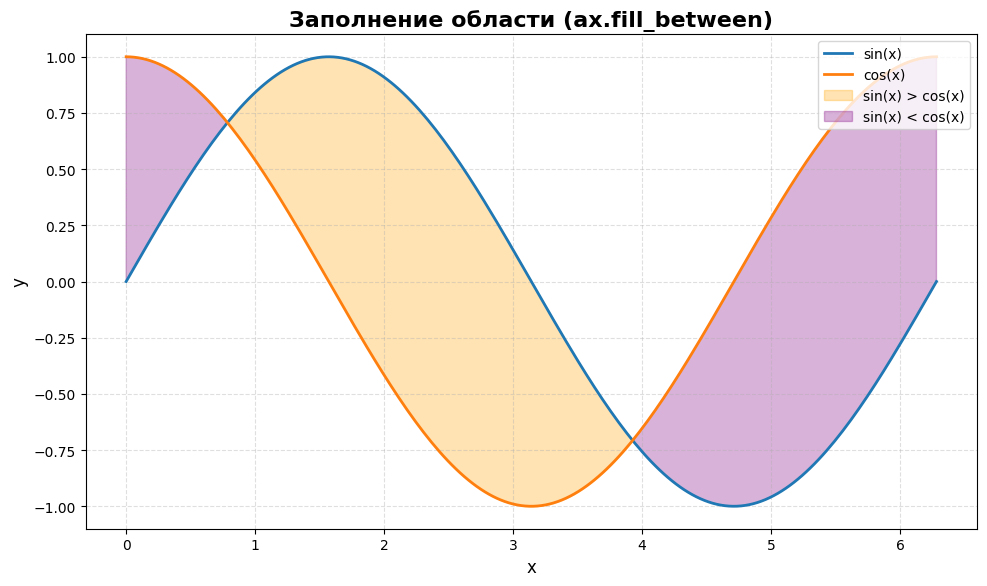

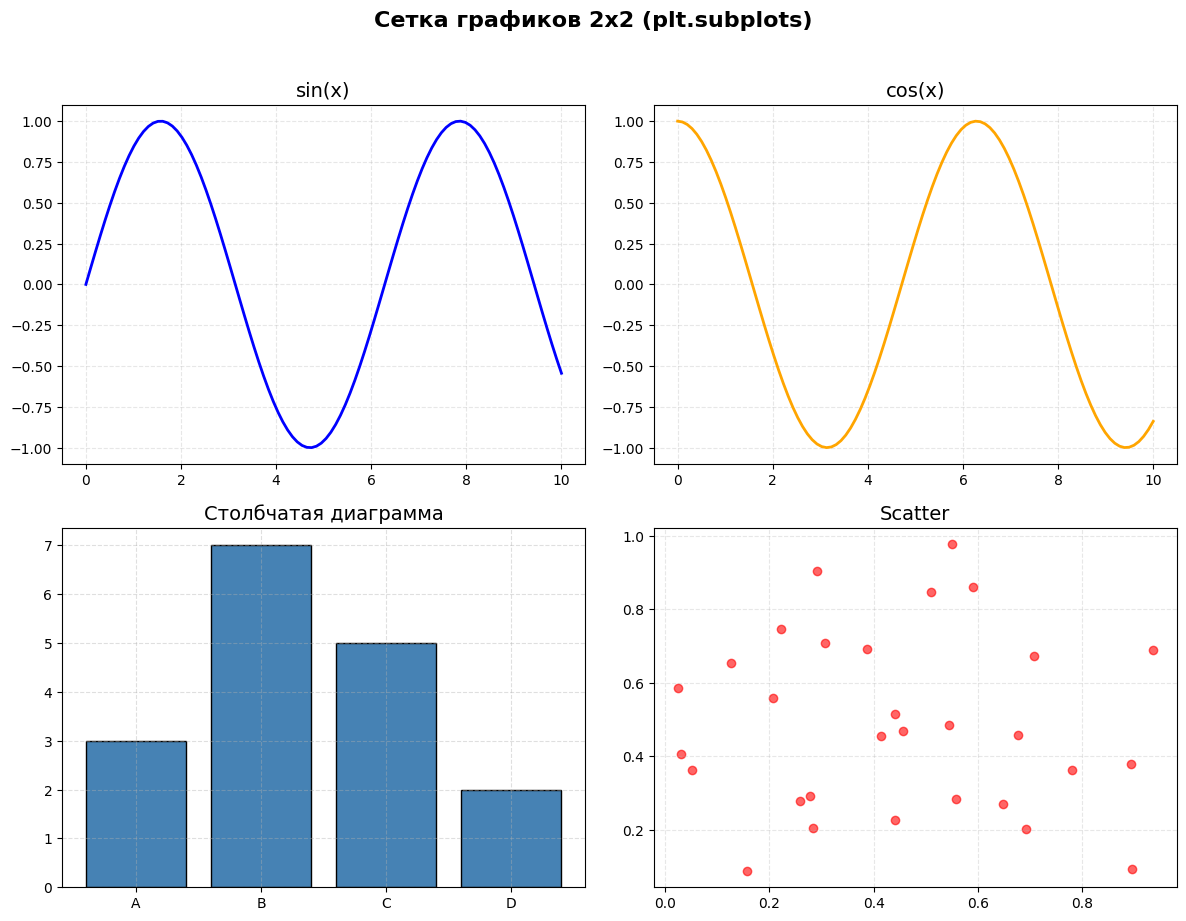

Файл 'my_plot.png' сохранён в текущую директорию.


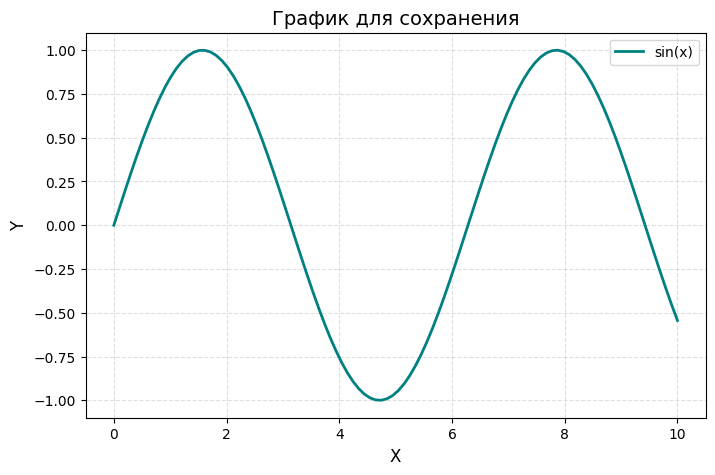

Все примеры завершены.


In [1]:
import matplotlib.pyplot as plt   # Модуль для построения графиков
import numpy as np                # Библиотека для работы с массивами и математикой


# ============================================================================
# ОБЩИЕ НАСТРОЙКИ MATPLOTLIB
# ============================================================================
# rcParams — глобальные параметры, влияющие на ВСЕ графики в текущей сессии.

plt.rcParams.update({
    'figure.figsize': (10, 6),       # Размер фигуры по умолчанию (ширина, высота) в дюймах
    'figure.dpi': 100,                # Разрешение фигуры (точек на дюйм)
    'font.size': 11,                  # Базовый размер шрифта
    'axes.titlesize': 14,             # Размер заголовка графика
    'axes.labelsize': 12,             # Размер подписей осей
    'xtick.labelsize': 10,            # Размер подписей делений оси X
    'ytick.labelsize': 10,            # Размер подписей делений оси Y
    'legend.fontsize': 10,            # Размер шрифта легенды
    'axes.grid': True,                # Включить сетку по умолчанию
    'grid.alpha': 0.4,                # Прозрачность сетки (0.0 — 1.0)
    'grid.linestyle': '--',           # Стиль линий сетки
    'lines.linewidth': 2,             # Толщина линий по умолчанию
    'figure.facecolor': 'white',      # Цвет фона фигуры
    'axes.facecolor': 'white',        # Цвет фона области графика
})



# ============================================================================
# 1. ЛИНЕЙНЫЙ ГРАФИК — ax.plot()
# ============================================================================
def example_line_plot():
    """
    Линейный график показывает изменение значений по непрерывной оси.
    Используется для отображения динамики: временные ряды, функции, тренды.

    Основные параметры ax.plot():
        x, y        — координаты точек (массивы одинаковой длины)
        color       — цвет линии (название, HEX-код, RGB-кортеж)
        linestyle   — стиль линии: '-' сплошная, '--' пунктир,
                      '-.' штрих-пунктир, ':' точечная
        linewidth   — толщина линии (в пунктах)
        marker      — форма маркера на точках: 'o' круг, 's' квадрат,
                      '^' треугольник, 'D' ромб, '*' звезда, '+' плюс
        markersize  — размер маркера
        markerfacecolor — цвет заливки маркера
        markeredgecolor — цвет границы маркера
        alpha       — прозрачность (0.0 полностью прозрачный, 1.0 непрозрачный)
        label       — подпись для легенды
    """
    # Генерируем данные: 100 равномерно распределённых точек от 0 до 10
    x = np.linspace(0, 10, 100)

    # Создаём фигуру и одну область графика (Axes)
    # figsize — размер холста в дюймах (ширина, высота)
    fig, ax = plt.subplots(figsize=(10, 6))

    # --- Первая линия: sin(x) ---
    ax.plot(
        x,                      # данные по оси X
        np.sin(x),              # данные по оси Y
        color='#2196F3',        # цвет в формате HEX (синий)
        linestyle='-',          # сплошная линия
        linewidth=2.5,          # толщина линии
        marker='o',             # маркер в виде круга на каждой точке
        markersize=5,           # размер маркера
        markerfacecolor='white',# заливка маркера белым
        markeredgecolor='#2196F3', # граница маркера синяя
        alpha=0.9,              # лёгкая прозрачность
        label='sin(x)'          # подпись для легенды
    )

    # --- Вторая линия: cos(x) ---
    ax.plot(
        x,
        np.cos(x),
        color='coral',          # цвет по названию
        linestyle='--',         # пунктирная линия
        linewidth=2,
        marker='s',             # квадратные маркеры
        markersize=4,
        alpha=0.8,
        label='cos(x)'
    )

    # --- Третья линия: затухающая синусоида ---
    # Демонстрация стиля '-.' (штрих-пунктир) и точечных маркеров
    ax.plot(
        x,
        np.exp(-0.3 * x) * np.sin(2 * x),
        color='green',
        linestyle='-.',
        linewidth=1.5,
        marker='^',
        markersize=6,
        markevery=5,            # рисовать маркер только на каждой 5-й точке
        label='Затухающая синусоида'
    )

    # --- Настройка заголовка и подписей осей ---
    ax.set_title('Линейные графики (ax.plot)', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Ось X', fontsize=12, labelpad=10)   # labelpad — отступ подписи от оси
    ax.set_ylabel('Ось Y', fontsize=12)

    # --- Пределы осей ---
    # set_xlim / set_ylim задают видимый диапазон графика
    ax.set_xlim(0, 10)
    ax.set_ylim(-1.5, 1.5)

    # --- Деления на осях ---
    # set_xticks / set_yticks задают положения делений
    ax.set_xticks(np.arange(0, 11, 1))  # от 0 до 10 с шагом 1

    # --- Сетка ---
    ax.grid(True, linestyle='--', alpha=0.4, color='gray')

    # --- Легенда ---
    # loc — расположение: 'upper right', 'upper left', 'lower right',
    #      'lower left', 'center', 'best' (автоматически)
    # frameon — рисовать рамку вокруг легенды
    ax.legend(loc='upper right', frameon=True, shadow=True)

    # --- Аннотация (текст со стрелкой) ---
    # xy — точка, на которую указывает стрелка
    # xytext — где размещается текст
    ax.annotate(
        'Максимум sin(x)',
        xy=(np.pi / 2, 1),          # координаты точки
        xytext=(3, 1.3),             # координаты текста
        fontsize=10,
        arrowprops=dict(
            facecolor='black',       # цвет стрелки
            arrowstyle='->',         # стиль стрелки
            connectionstyle='arc3,rad=0.3'  # изгиб стрелки
        )
    )

    # --- Обычный текст на графике ---
    ax.text(7, -1.2, 'Текст на графике', fontsize=10, color='gray', style='italic')

    plt.tight_layout()  # автоматически подгоняет отступы
    plt.show()


# ============================================================================
# 2. ДИАГРАММА РАССЕЯНИЯ — ax.scatter()
# ============================================================================
def example_scatter_plot():
    """
    Диаграмма рассеяния отображает пары значений (x, y) в виде точек.
    Используется для визуализации корреляций, кластеров, распределений.

    Основные параметры ax.scatter():
        x, y        — координаты точек
        s           — размер точек (скаляр или массив для разных размеров)
        c           — цвет точек: одно значение или массив для цветовой карты
        cmap        — цветовая палитра: 'viridis', 'plasma', 'coolwarm',
                      'hot', 'jet', 'RdYlGn' и др.
        alpha       — прозрачность точек
        marker      — форма маркера
        edgecolors  — цвет границы маркера
        linewidths  — толщина границы маркера
    """
    np.random.seed(42)  # фиксируем генератор для воспроизводимости

    # Генерируем 80 случайных точек
    x = np.random.rand(80)
    y = np.random.rand(80)

    # Массив значений для раскраски (будет использоваться цветовая карта)
    colors = np.random.rand(80)

    # Массив размеров точек (каждая точка своего размера)
    sizes = np.random.randint(20, 300, 80)

    fig, ax = plt.subplots(figsize=(10, 7))

    # scatter возвращает объект PathCollection, который можно передать в colorbar
    scatter = ax.scatter(
        x, y,
        c=colors,              # значения для цветовой карты
        cmap='viridis',        # палитра (от тёмно-синего к жёлтому)
        s=sizes,               # размеры точек
        alpha=0.7,             # прозрачность
        edgecolors='black',    # чёрная граница каждой точки
        linewidths=0.8         # толщина границы
    )

    # --- Цветовая шкала (colorbar) ---
    # Отображает соответствие цвета и числового значения
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('Значение цвета', fontsize=11)

    ax.set_title('Диаграмма рассеяния (ax.scatter)', fontsize=16, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    # --- Пределы осей с небольшим отступом ---
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()


# ============================================================================
# 3. СТОЛБЧАТАЯ ДИАГРАММА — ax.bar() / ax.barh()
# ============================================================================
def example_bar_chart():
    """
    Столбчатая диаграмма используется для сравнения величин по категориям.
    bar()  — вертикальные столбцы
    barh() — горизонтальные столбцы

    Основные параметры ax.bar():
        x           — позиции столбцов (или названия категорий)
        height      — высоты столбцов
        width       — ширина столбцов (по умолчанию 0.8)
        color       — цвет столбцов (один цвет или список)
        edgecolor   — цвет границы столбцов
        linewidth   — толщина границы
        alpha       — прозрачность
        align       — выравнивание: 'center' (по центру позиции)
                      или 'edge' (по краю позиции)
        log         — True для логарифмической шкалы
    """
    # Категории и соответствующие значения
    categories = ['Яблоки', 'Бананы', 'Апельсины', 'Груши', 'Виноград']
    values = [120, 90, 150, 60, 110]

    # Индивидуальные цвета для каждого столбца
    colors = ['#e74c3c', '#f1c40f', '#e67e22', '#2ecc71', '#9b59b6']

    fig, ax = plt.subplots(figsize=(10, 6))

    # bar() возвращает контейнер BarContainer с объектами Rectangle
    bars = ax.bar(
        categories,            # категории по оси X
        values,                # высоты столбцов
        color=colors,          # цвета
        edgecolor='black',     # чёрная граница
        linewidth=1.2,         # толщина границы
        width=0.6,             # ширина столбцов (меньше = уже)
        alpha=0.85             # лёгкая прозрачность
    )

    # --- Подписи значений над каждым столбцом ---
    # Проходим по каждому столбцу и добавляем текст сверху
    for bar in bars:
        height = bar.get_height()          # высота столбца
        x_pos = bar.get_x() + bar.get_width() / 2  # центр столбца по X
        ax.text(
            x_pos,               # позиция текста по X
            height + 2,          # позиция текста по Y (чуть выше столбца)
            f'{height}',         # отображаемое значение
            ha='center',         # горизонтальное выравнивание (center, left, right)
            va='bottom',         # вертикальное выравнивание (bottom, top, center)
            fontsize=11,
            fontweight='bold'
        )

    ax.set_title('Столбчатая диаграмма (ax.bar)', fontsize=16, fontweight='bold')
    ax.set_xlabel('Фрукты')
    ax.set_ylabel('Продажи (кг)')

    # Устанавливаем предел по Y с запасом для подписей
    ax.set_ylim(0, max(values) * 1.15)

    # --- Горизонтальная линия среднего значения ---
    mean_value = np.mean(values)
    ax.axhline(
        y=mean_value,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'Среднее: {mean_value:.1f}'
    )

    ax.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================================
    # ГОРИЗОНТАЛЬНАЯ СТОЛБЧАТАЯ ДИАГРАММА — ax.barh()
    # =====================================================================
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.barh(
        categories,            # категории по оси Y
        values,                # длины столбцов
        color=colors,
        edgecolor='black',
        height=0.5,            # высота (толщина) горизонтальных столбцов
        alpha=0.85
    )

    ax.set_title('Горизонтальная столбчатая диаграмма (ax.barh)', fontsize=14)
    ax.set_xlabel('Продажи (кг)')
    ax.invert_yaxis()  # инвертируем ось Y, чтобы первая категория была сверху

    plt.tight_layout()
    plt.show()


# ============================================================================
# 4. ГИСТОГРАММА РАСПРЕДЕЛЕНИЯ — ax.hist()
# ============================================================================
def example_histogram():
    """
    Гистограмма показывает распределение числовых данных:
    разбивает диапазон значений на интервалы (bins) и отображает
    количество попаданий в каждый интервал.

    Основные параметры ax.hist():
        x           — входной массив данных
        bins        — количество интервалов или список границ интервалов
        range       — кортеж (min, max) для диапазона данных
        density     — True: нормировка так, чтобы площадь = 1
                      (отображается плотность вероятности)
        cumulative  — True: накопительная гистограмма
        histtype    — тип гистограммы:
                      'bar' — столбцы (по умолчанию)
                      'barstacked' — стопка столбцов
                      'step' — только контур
                      'stepfilled' — заполненный контур
        color       — цвет столбцов
        edgecolor   — цвет границ
        alpha       — прозрачность
    """
    np.random.seed(0)

    # Генерируем 1000 значений нормального распределения
    # loc — среднее, scale — стандартное отклонение
    data = np.random.normal(loc=50, scale=12, size=1000)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(
        data,
        bins=25,               # 25 интервалов
        color='steelblue',
        edgecolor='black',     # чёрные границы столбцов
        linewidth=0.8,
        alpha=0.75,
        density=False          # False — абсолютные частоты
        # density=True         # True — плотность вероятности
    )

    # --- Вертикальная линия среднего значения ---
    ax.axvline(
        x=data.mean(),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Среднее: {data.mean():.1f}'
    )

    # --- Вертикальные линии стандартных отклонений ---
    ax.axvline(
        x=data.mean() - data.std(),
        color='orange',
        linestyle=':',
        linewidth=1.5,
        label=f'-1σ ({data.mean() - data.std():.1f})'
    )
    ax.axvline(
        x=data.mean() + data.std(),
        color='orange',
        linestyle=':',
        linewidth=1.5,
        label=f'+1σ ({data.mean() + data.std():.1f})'
    )

    ax.set_title('Гистограмма распределения (ax.hist)', fontsize=16, fontweight='bold')
    ax.set_xlabel('Значение')
    ax.set_ylabel('Частота')
    ax.legend()

    plt.tight_layout()
    plt.show()


# ============================================================================
# 5. КРУГОВАЯ ДИАГРАММА — ax.pie()
# ============================================================================
def example_pie_chart():
    """
    Круговая диаграмма отображает доли частей от целого.

    Основные параметры ax.pie():
        x           — значения долей (сумма определяет целое)
        labels      — подписи сегментов
        autopct     — формат отображения процентов, например '%1.1f%%'
        startangle  — угол начала отрисовки (в градусах, против часовой)
        explode     — кортеж смещений сегментов от центра
                      (0 — на месте, >0 — выдвинут)
        colors      — список цветов
        shadow      — True: рисовать тень
        wedgeprops  — словарь свойств сегментов:
                      {'edgecolor': 'black', 'linewidth': 1, 'alpha': 0.9}
        pctdistance — расстояние процентов от центра (0–1)
        textprops   — свойства текста подписей
    """
    labels = ['Категория A', 'Категория B', 'Категория C', 'Категория D']
    sizes = [40, 25, 20, 15]
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

    # Выдвигаем первый сегмент из круга (эффект «разрыва»)
    explode = (0.08, 0, 0, 0)

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',       # проценты с одним знаком после запятой
        startangle=90,           # начинаем с 90 градусов (сверху)
        explode=explode,
        colors=colors,
        shadow=True,             # тень под диаграммой
        wedgeprops={
            'edgecolor': 'black',
            'linewidth': 1.5,
            'alpha': 0.9
        },
        textprops={'fontsize': 12}
    )

    ax.set_title('Круговая диаграмма (ax.pie)', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()


# ============================================================================
# 6. ЯЩИК С УСАМИ — ax.boxplot()
# ============================================================================
def example_boxplot():
    """
    Boxplot отображает статистическое распределение данных:
    — медиана (линия внутри ящика)
    — квартили (границы ящика: Q1 и Q3)
    — усы (1.5 * IQR от квартилей)
    — выбросы (точки за пределами усов)

    Основные параметры ax.boxplot():
        x           — данные (список массивов для нескольких групп)
        vert        — True: вертикальный, False: горизонтальный
        patch_artist— True: разрешить заливку ящиков цветом
        notch       — True: «выемка» вокруг медианы (доверительный интервал)
        showfliers  — True: показывать выбросы (по умолчанию True)
        boxprops    — стиль ящика (dict)
        medianprops — стиль линии медианы
        whiskerprops— стиль усов
        capprops    — стиль «шапочек» усов
        flierprops  — стиль выбросов
        labels      — подписи групп
    """
    np.random.seed(1)

    # Три группы данных с разными параметрами распределения
    data = [
        np.random.normal(0, 1, 100),      # среднее 0, std 1
        np.random.normal(2, 1.5, 100),    # среднее 2, std 1.5
        np.random.normal(4, 0.8, 100),    # среднее 4, std 0.8
    ]

    fig, ax = plt.subplots(figsize=(10, 6))

    bp = ax.boxplot(
        data,
        patch_artist=True,         # включаем заливку цветом
        vert=True,                 # вертикальная ориентация
        notch=False,               # без выемки
        showfliers=True,           # показывать выбросы
        labels=['Группа 1', 'Группа 2', 'Группа 3'],

        # Стиль ящиков (прямоугольников)
        boxprops=dict(
            facecolor='lightblue',
            color='navy',
            linewidth=1.5
        ),

        # Стиль линии медианы
        medianprops=dict(
            color='red',
            linewidth=2.5
        ),

        # Стиль усов
        whiskerprops=dict(
            color='navy',
            linewidth=1.5,
            linestyle='-'
        ),

        # Стиль «шапочек» на концах усов
        capprops=dict(
            color='navy',
            linewidth=1.5
        ),

        # Стиль выбросов
        flierprops=dict(
            marker='o',
            markerfacecolor='orange',
            markersize=7,
            markeredgecolor='darkorange',
            alpha=0.8
        )
    )

    ax.set_title('Ящик с усами (ax.boxplot)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Значения')

    plt.tight_layout()
    plt.show()


# ============================================================================
# 7. ТЕПЛОВАЯ КАРТА / ИЗОБРАЖЕНИЕ — ax.imshow()
# ============================================================================
def example_heatmap():
    """
    imshow() отображает двумерный массив в виде цветовой матрицы.
    Используется для тепловых карт, изображений, матриц корреляций.

    Основные параметры ax.imshow():
        X             — двумерный массив данных
        cmap          — цветовая палитра:
                        'viridis', 'plasma', 'hot', 'coolwarm',
                        'jet', 'gray', 'RdYlGn', 'Blues' и др.
        vmin, vmax    — минимальное и максимальное значение для шкалы цвета
        interpolation — метод интерполяции между пикселями:
                        'nearest', 'bilinear', 'spline16', 'bicubic'
        aspect        — соотношение сторон: 'equal', 'auto'
        origin        — расположение начала координат: 'upper', 'lower'
    """
    np.random.seed(2)

    # Создаём случайную матрицу 6x6
    matrix = np.random.rand(6, 6)

    fig, ax = plt.subplots(figsize=(8, 7))

    # imshow возвращает объект AxesImage
    im = ax.imshow(
        matrix,
        cmap='hot',              # цветовая палитра (чёрный → красный → жёлтый)
        interpolation='nearest', # без сглаживания пикселей
        vmin=0,                  # минимальное значение шкалы цвета
        vmax=1,                  # максимальное значение шкалы цвета
        aspect='equal'           # квадратные ячейки
    )

    # --- Цветовая шкала ---
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Значение', fontsize=11)

    # --- Подписи осей ---
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['C1', 'C2', 'C3', 'C4', 'C5', 'C6'])
    ax.set_yticklabels(['R1', 'R2', 'R3', 'R4', 'R5', 'R6'])

    # --- Текст в каждой ячейке матрицы ---
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            # Определяем цвет текста в зависимости от значения ячейки
            text_color = 'white' if matrix[i, j] < 0.5 else 'black'
            ax.text(
                j, i,                        # координаты (столбец, строка)
                f'{matrix[i, j]:.2f}',       # текст с 2 знаками после запятой
                ha='center',                 # центр по горизонтали
                va='center',                 # центр по вертикали
                color=text_color,
                fontsize=10,
                fontweight='bold'
            )

    ax.set_title('Тепловая карта (ax.imshow)', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()


# ============================================================================
# 8. ГРАФИК С ПОГРЕШНОСТЯМИ — ax.errorbar()
# ============================================================================
def example_errorbar():
    """
    errorbar() отображает точки с планками погрешностей.
    Используется для визуализации неопределённости измерений.

    Основные параметры ax.errorbar():
        x, y       — координаты точек
        yerr       — погрешность по Y (скаляр или массив)
        xerr       — погрешность по X
        fmt        — формат маркера и линии, например 'o-', 's--', '^:'
        color      — цвет линии и маркеров
        ecolor     — цвет планок погрешностей
        elinewidth — толщина линий погрешностей
        capsize    — ширина засечек на концах планок
        capthick   — толщина засечек
        barsabove  — True: рисовать планки поверх линии
    """
    # Данные измерений
    x = np.arange(1, 6)
    y = np.array([2.1, 4.3, 3.2, 5.1, 4.4])

    # Погрешности по Y (для каждой точки своя)
    yerr = np.array([0.2, 0.4, 0.3, 0.5, 0.35])

    # Погрешности по X (можно тоже задать)
    xerr = np.array([0.1, 0.1, 0.15, 0.1, 0.1])

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.errorbar(
        x, y,
        yerr=yerr,               # погрешность по Y
        xerr=xerr,               # погрешность по X
        fmt='o-',                # круглые маркеры со сплошной линией
        color='darkgreen',       # цвет маркеров и линии
        ecolor='gray',           # цвет планок погрешностей
        elinewidth=1.5,          # толщина линий погрешностей
        capsize=6,               # ширина засечек
        capthick=1.5,            # толщина засечек
        markersize=8,
        markerfacecolor='white',
        markeredgecolor='darkgreen',
        markeredgewidth=2,
        label='Измерения',
        barsabove=True           # планки поверх линии
    )

    ax.set_title('График с погрешностями (ax.errorbar)', fontsize=16, fontweight='bold')
    ax.set_xlabel('Номер измерения')
    ax.set_ylabel('Значение')
    ax.legend()

    plt.tight_layout()
    plt.show()


# ============================================================================
# 9. ЗАПОЛНЕНИЕ ОБЛАСТИ — ax.fill_between()
# ============================================================================
def example_fill_between():
    """
    fill_between() заполняет цветом область между двумя линиями.
    Используется для отображения доверительных интервалов, областей.

    Основные параметры ax.fill_between():
        x           — координаты по оси X
        y1, y2      — нижняя и верхняя границы заполнения
        where       — условие (булев массив): заполнять только там, где True
        alpha       — прозрачность заполнения
        color       — цвет заполнения
        interpolate — True: точно вычислять точки пересечения линий
        label       — подпись для легенды
    """
    x = np.linspace(0, 2 * np.pi, 200)
    y1 = np.sin(x)
    y2 = np.cos(x)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(x, y1, label='sin(x)', linewidth=2)
    ax.plot(x, y2, label='cos(x)', linewidth=2)

    # --- Заполнение там, где sin(x) > cos(x) ---
    ax.fill_between(
        x, y1, y2,
        where=(y1 > y2),         # условие: заполнять только где sin > cos
        alpha=0.3,
        color='orange',
        interpolate=True,        # точные точки пересечения
        label='sin(x) > cos(x)'
    )

    # --- Заполнение там, где sin(x) < cos(x) ---
    ax.fill_between(
        x, y1, y2,
        where=(y1 < y2),
        alpha=0.3,
        color='purple',
        interpolate=True,
        label='sin(x) < cos(x)'
    )

    ax.set_title('Заполнение области (ax.fill_between)', fontsize=16, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


# ============================================================================
# 10. СЕТКА ГРАФИКОВ — plt.subplots()
# ============================================================================
def example_subplots():
    """
    plt.subplots() создаёт фигуру с сеткой графиков.

    Основные параметры plt.subplots():
        nrows, ncols — количество строк и столбцов
        figsize      — размер всей фигуры
        sharex       — True: общая ось X для всех подграфиков
        sharey       — True: общая ось Y
        subplot_kw   — словарь доп. параметров для каждого Axes
        gridspec_kw  — словарь для настройки ширины/высоты строк/столбцов

    Возвращает:
        fig  — объект Figure (холст)
        axes — массив объектов Axes (или один Axes, если сетка 1x1)
    """
    x = np.linspace(0, 10, 100)

    # Создаём сетку 2 строки x 2 столбца
    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(12, 9),
        # sharex=True,   # раскомментировать для общей оси X
        # sharey=True,   # раскомментировать для общей оси Y
    )

    # axes — это двумерный массив: axes[строка, столбец]

    # --- График 1: sin(x) ---
    axes[0, 0].plot(x, np.sin(x), color='blue', linewidth=2)
    axes[0, 0].set_title('sin(x)')
    axes[0, 0].grid(True, alpha=0.3)

    # --- График 2: cos(x) ---
    axes[0, 1].plot(x, np.cos(x), color='orange', linewidth=2)
    axes[0, 1].set_title('cos(x)')
    axes[0, 1].grid(True, alpha=0.3)

    # --- График 3: столбчатая диаграмма ---
    axes[1, 0].bar(['A', 'B', 'C', 'D'], [3, 7, 5, 2], color='steelblue', edgecolor='black')
    axes[1, 0].set_title('Столбчатая диаграмма')

    # --- График 4: диаграмма рассеяния ---
    np.random.seed(3)
    axes[1, 1].scatter(np.random.rand(30), np.random.rand(30), color='red', alpha=0.6)
    axes[1, 1].set_title('Scatter')
    axes[1, 1].grid(True, alpha=0.3)

    # --- Общий заголовок для всей фигуры ---
    fig.suptitle('Сетка графиков 2x2 (plt.subplots)', fontsize=16, fontweight='bold', y=1.02)

    # --- Автоматическая подгонка отступов ---
    plt.tight_layout()

    plt.show()


# ============================================================================
# 11. СОХРАНЕНИЕ ГРАФИКА В ФАЙЛ
# ============================================================================
def example_save_figure():
    """
    fig.savefig() сохраняет фигуру в файл.

    Основные параметры savefig():
        fname        — имя файла или путь
        dpi          — разрешение (300 для печати, 150 для экрана)
        bbox_inches  — 'tight': автоматически обрезает пустые поля
        facecolor    — цвет фона
        format       — формат файла: 'png', 'pdf', 'svg', 'eps', 'jpg'
        transparent  — True: прозрачный фон (полезно для PNG/SVG)
    """
    x = np.linspace(0, 10, 100)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, np.sin(x), color='teal', linewidth=2, label='sin(x)')
    ax.set_title('График для сохранения')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()

    # --- Сохранение в разных форматах ---
    # PNG — растровый формат (хорош для веба и презентаций)
    fig.savefig(
        'my_plot.png',
        dpi=300,                 # высокое разрешение
        bbox_inches='tight',     # обрезать пустые поля
        facecolor='white'        # белый фон
    )

    # PDF — векторный формат (хорош для статей и печати)
    # fig.savefig('my_plot.pdf', bbox_inches='tight')

    # SVG — векторный формат (хорош для веба)
    # fig.savefig('my_plot.svg', bbox_inches='tight')

    print("Файл 'my_plot.png' сохранён в текущую директорию.")

    plt.show()


# ============================================================================
# ГЛАВНАЯ СЕКЦИЯ — ЗАПУСК ПРИМЕРОВ
# ============================================================================
if __name__ == '__main__':
    # Запускаем все примеры по очереди.
    # Каждый пример откроет отдельное окно с графиком.
    # Закройте окно, чтобы перейти к следующему примеру.

    print("=" * 60)
    print(" Matplotlib: Демонстрация основных типов графиков")
    print("=" * 60)

    # Раскомментируйте нужные примеры или запустите все:

    example_line_plot()       # 1. Линейный график
    example_scatter_plot()    # 2. Диаграмма рассеяния
    example_bar_chart()       # 3. Столбчатая диаграмма (вертикальная + горизонтальная)
    example_histogram()       # 4. Гистограмма распределения
    example_pie_chart()       # 5. Круговая диаграмма
    example_boxplot()         # 6. Ящик с усами
    example_heatmap()         # 7. Тепловая карта
    example_errorbar()        # 8. График с погрешностями
    example_fill_between()    # 9. Заполнение области
    example_subplots()        # 10. Сетка графиков
    example_save_figure()     # 11. Сохранение в файл

    print("Все примеры завершены.")